# destine-fdb quickstart

Open a DestinE Climate DT run from a local FDB

You need
`pyfdb` pointed at a matching `libfdb5.so`:

```bash
export FDB5_DIR=/path/to/climateDT/build_intel
export LD_LIBRARY_PATH=$FDB5_DIR/lib:$LD_LIBRARY_PATH
```


## 1. Pass FDB

Pass the FDB **root directory** — the one holding `etc/fdb/config.yaml`.
That also sets `FDB_HOME`, which the shared DestinE config needs to resolve
its schema (`~fdb/etc/fdb/schema`).

In [1]:
FDB = "/gpfs/scratch/ehpc123/sbeyer/fdb_manual_storylines/healpix"

RUN = dict(
    activity="story-nudging",
    experiment="hist",
    member=1,              # the `realization` key
    frequency="hourly",    # -> clte stream ('monthly' -> clmn)
    resolution="high",     # the FDB's key, not a target grid
    levtype="sfc",
)

## 2. What runs are in this FDB?

Start here on an FDB you don't know. This reads database *directory names*,
so it never opens an index — 828 runs over ~190,000 databases on the shared
DestinE FDB in under a second.

`covers` is there because a raw database count is not a unit anyone thinks in.
The Climate DT schema keys a database on `date` for the hourly and daily
streams and on `year` for the monthly one, so **one database is one day for
`clte` and one year for `clmn`**.


In [2]:
import destine_fdb

cols = ["activity", "experiment", "model", "realization", "stream",
        "covers", "first", "last"]
print(destine_fdb.runs(FDB)[cols].to_string(index=False))

     activity experiment     model realization stream  covers    first     last
story-nudging       cont ifs-fesom           1   clte 29 days 20260501 20260529
story-nudging       hist ifs-fesom           1   clte 29 days 20260501 20260529
story-nudging  tplus2.0k ifs-fesom           1   clte 29 days 20260501 20260529


## 3. What is actually in there?

`scan_run` reads the FDB index rather than trusting a table, which matters
because the runs worth reading from an FDB are often the partial ones.
`scan_mode="filesystem"` reads database *directory names* instead — much
faster on long hourly runs, same answer.

In [3]:
found = destine_fdb.scan_run(FDB, scan_mode="filesystem", **RUN)
print(f"{len(found['times'])} timesteps: "
      f"{'/'.join(found['times'][0])} .. {'/'.join(found['times'][-1])}")
print(f"{len(found['params'])} params archived")

673 timesteps: 20260501/0000 .. 20260529/0000
36 params archived


## 4. What else is in this run?

`open_run` opens **one levtype at a time**, so with no `variables=` you get
every variable of one family (`sfc` by default). `overview` shows all of them
at once, which is the thing to look at on an unfamiliar run — note the ocean
is daily where the atmosphere is hourly, and that `o3d` really has 70 levels
rather than the 75 the catalogue pads to.


In [4]:
cols = ["levtype", "freq", "variables", "timesteps", "first", "last", "levels"]

# overview() reports every levtype, so it takes no levtype= of its own.
run = {k: v for k, v in RUN.items() if k != "levtype"}
print(destine_fdb.overview(FDB, **run)[cols].to_string(index=False))

levtype         freq  variables  timesteps         first          last  levels
    sfc daily/hourly         36        673 20260501/0000 20260529/0000       0
    o2d        daily         12         28 20260501/0000 20260528/0000       0
    o3d        daily          5         28 20260501/0000 20260528/0000      70
     pl       hourly          9        673 20260501/0000 20260529/0000      19
    sol       hourly          3        673 20260501/0000 20260529/0000       5
     hl       hourly          2        673 20260501/0000 20260529/0000       1


## 5. Open it

Nothing is read yet. The dataset knows its shape, variables and time axis;
each dask chunk is one FDB request, issued only when you touch values.

In [5]:
ds = destine_fdb.open_run(FDB, scan_mode="filesystem", **RUN)
ds

<xarray.Dataset> Size: 288GB
Dimensions:       (time: 673, cell: 3145728)
Coordinates:
  * time          (time) datetime64[us] 5kB 2026-05-01 ... 2026-05-29
  * cell          (cell) int32 13MB 0 1 2 3 ... 3145724 3145725 3145726 3145727
    crs           int8 1B 0
Data variables: (12/34)
    tclw          (time, cell) float32 8GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    tciw          (time, cell) float32 8GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    sp            (time, cell) float32 8GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    tcw           (time, cell) float32 8GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    tcwv          (time, cell) float32 8GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    sd            (time, cell) float32 8GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    ...            ...
    avg_tnswrfcs  (time, cell) float32 8GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    avg_tnlwrfcs  (time, cell) float32 8GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    avg_snswrfcs  (time, cell) float32 8GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    avg_snlwrfcs  (time, cell) float32 8GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    avg_tdswrf    (time, cell) float32 8GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
    avg_tprate    (time, cell) float32 8GB dask.array<chunksize=(24, 3145728), meta=np.ndarray>
Attributes:
    activity:         story-nudging
    experiment:       hist
    realization:      1
    resolution:       high
    levtype:          sfc
    stream:           clte
    nside:            512
    grid:             H512
    indexing_scheme:  nested
    healpix_nside:    512
    healpix_nest:     True
    source:           local FDB via destine_fdb

In [6]:
print(f"{ds.nbytes / 1e9:.0f} GB if it were all in memory")
print(f"chunks: {ds['2t'].chunks[0][:3]}...  (one chunk = one FDB request)")
print(f"grid:   {ds.attrs['grid']}, {ds.cell.attrs}")

288 GB if it were all in memory
chunks: (24, 24, 24)...  (one chunk = one FDB request)
grid:   H512, {'grid_name': 'healpix', 'level': 9, 'indexing_scheme': 'nested'}


## 6. Plot map

Data is on the native HEALPix mesh — a 1-D `cell` dimension — so a plain
`.plot()` would give a line plot. `easygems.healpix_show` resamples the cells
onto the screen raster of a cartopy axes.

**Set the map extent before calling it**: it samples whatever extent the axes
currently has, so a default-extent axes gives a blank map.

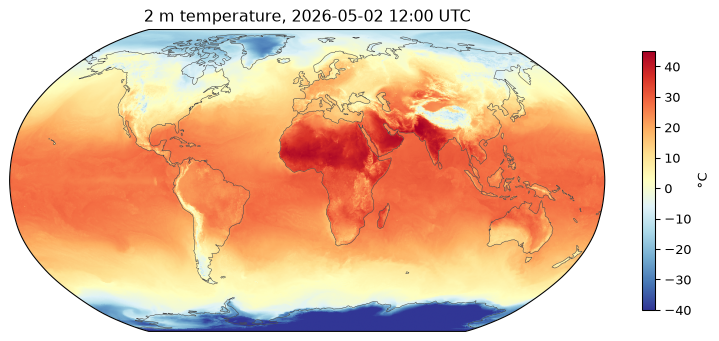

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import easygems.healpix as egh

field = ds["2t"].sel(time="2026-05-02T12:00") - 273.15   # one FDB request

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": ccrs.Robinson()})
ax.set_global()                                          # BEFORE healpix_show
im = egh.healpix_show(field, ax=ax, cmap="RdYlBu_r", vmin=-40, vmax=45)
ax.coastlines(linewidth=0.4, color="0.3")
ax.set_title("2 m temperature, 2026-05-02 12:00 UTC")
plt.colorbar(im, ax=ax, shrink=0.7, label="°C");

Zooming costs nothing extra — the same single field is resampled to the new
extent, so no more data is read.

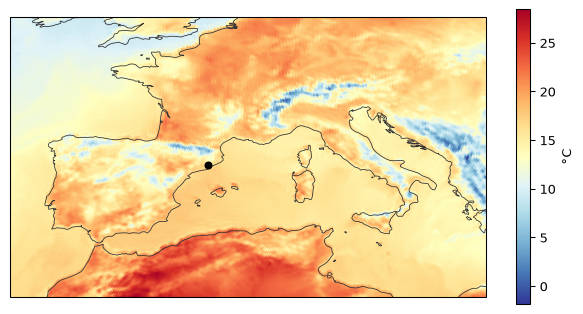

In [8]:
fig, ax = plt.subplots(figsize=(8, 5),
                       subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-12, 22, 32, 52], crs=ccrs.PlateCarree())
im = egh.healpix_show(field, ax=ax, cmap="RdYlBu_r")
ax.coastlines(linewidth=0.6, color="0.2")
ax.plot(2.17, 41.39, "ko", ms=5, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink=0.8, label="°C");

## 7. A timeseries

Pick the HEALPix cell containing a point, then select it. Reading 168 hourly
steps is 7 requests (one per calendar day); dask threads run them
concurrently.

Barcelona -> H512 cell 174662


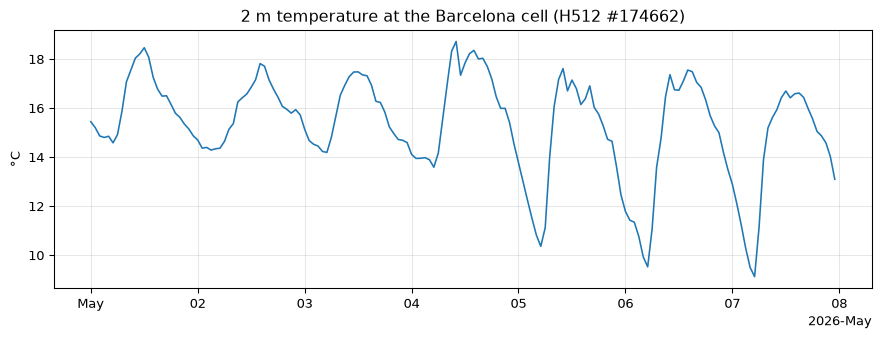

In [9]:
import healpy as hp
import dask

nside = ds.attrs["healpix_nside"]
cell = int(hp.ang2pix(nside, 2.17, 41.39, nest=True, lonlat=True))  # Barcelona
print(f"Barcelona -> H{nside} cell {cell}")

with dask.config.set(scheduler="threads", num_workers=4):
    series = ds["2t"].isel(cell=cell).sel(
        time=slice("2026-05-01", "2026-05-07T23:00")).compute() - 273.15

fig, ax = plt.subplots(figsize=(11, 3.5))
series.plot(ax=ax, lw=1.2)
ax.set_title(f"2 m temperature at the Barcelona cell (H{nside} #{cell})")
ax.set_ylabel("°C"); ax.set_xlabel(""); ax.grid(alpha=0.3);

## 8. Where to go next

**Skip the scan** when you already know the range — this makes opening
instant, which is worth it on a long hourly run:

```python
ds = destine_fdb.open_run(FDB, start="2026-05-01", end="2026-05-07T23:00", **RUN)
```

**Use the DGGS tooling** — the `cell` coordinate carries standard grid
metadata, so [xdggs](https://github.com/xarray-contrib/xdggs) decodes it:

```python
import xdggs
decoded = xdggs.decode(ds, name="cell")   # name= because xdggs defaults to 'cell_ids'
decoded.dggs.grid_info                     # HealpixInfo(level=9, indexing_scheme='nested')
```

**Attach lat/lon** with `open_run(..., add_latlon=True)` for `.where()` masks
or region selection — the same coordinates `easygems.attach_coords` adds.